예제 실행 및 시각화를 위해 공통 라이브러리를 불러온다.
(공통 라이브러리에 대한 설명은 code_reference/README.md 파일을 참조)

In [1]:
# 코랩 환경 등 깃허브 전체를 clone해서 실습하는 경우가 아니라면 
# 공통 라이브러리를 불러오기 위해서 별도의 과정이 필요하므로 code_reference/README.md 파일을 확인하자.
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz
# 시각화 결과를 파일에 저장하지 않음
viz.configure(save_grayscale=False)

# matplotlib에서 한글 폰트를 사용 설정
common.set_korean_plot_env()

- 다음 셀은 결과 재현성을 보장하기 위해서 시드를 고정한다. 여기서 재현성은 '동일 컴퓨터, 동일 버전의 파이썬, 동일 버전의 파이토치' 환경에서 재현이 가능하다는 의미로, 독자의 결과는 저자의 결과와 달라질 수 있다는 점을 밝혀둔다.- 시드값에 따라 파라미터 초기값이 달라져 결과가 달라질 수 있다.
- 여기서 지정하는 시드값 2은 저자의 환경에서 본문과 같은 결과가 나오는 시드값으로, 같은 시드값을 사용하더라도 각자 실습 환경에 따라 결과가 달라질 수 있다.
- 대부분의 예제에서 지정한 시드값은 결과 재현을 위한 용도일 뿐, 예제의 본질과 무관하다. 여러 시드값을 통해 결과를 확인하는 일부 예외가 있으나, 결과가 달라지더라도 설명하는 내용의 본질이 달라지지 않는다.

In [2]:
import random
import numpy as np
import torch

SEED = 2
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 2-2 퍼셉트론으로 동작하는 딥러닝 모델

본 노트북은 본문 2-2절의 코드 예제와 관련 내용을 다룬다. 주요 내용은 다음과 같다.
- AND 게이트 시뮬레티어 퍼셉트론 모델 정의
- 손실 함수, 최적화 함수, 학습 함수 정의
- 모델 학습 및 생성한 결정 경계 시각화

본문의 모델 2의 구현에 해당되며, 모델 2의 제시문은 다음과 같다.

> **모델 2. AND 게이트 시뮬레이터 모델**
>
> 두 개의 숫자를 입력받아 하나의 숫자를 출력하는 다음과 같은 함수가 있다.
>
>   | 입력 1($x_1$) | 입력 2($x_2$) | 출력($y$) |
>   |:-----:|:-----:|:---:|
>   | 0 | 0 | 0 |
>   | 0 | 1 | 0 |
>   | 1 | 0 | 0 |
>   | 1 | 1 | 1 |
>
> 데이터를 학습해 이와 같이 동작하는 모델을 만들어 보자.


## AND 게이트 시뮬레이터의 학습 데이터
- 두 입력의 논리곱(AND)을 모사하는 4개 샘플을 입력 `X`와 정답 `Y_true` 텐서로 준비
    - `X`(입력 텐서): 두 개의 입력으로 구성된 4개의 입력 샘플 모음 텐서, `(4, 2)` 형태
    - `Y_true`(출력 텐서): 하나의 출력으로 구성된 4개의 출력 샘플 모음 텐서, `(4, 1)` 형태
      - `(4,)` 형태의 텐서가 아니라는 점에 주의
    - 4개 샘플 전부를 훈련 데이터로 사용하며, 별도의 평가용 데이터는 두지 않는다.



In [3]:
########################################################################################
# 코드 2-1 - AND 게이트 시뮬레이터의 학습 데이터
########################################################################################

import torch

X = torch.tensor([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
Y_true = torch.tensor([[0.], [0.], [0.], [1.]])
# 파이썬 리스트와 마찬가지로 len() 함수로 최상위 차원의 크기를 구할 수 있음(전체 요소의 개수가 아님)
print(f'데이터 샘플의 개수: {len(X)}')                                    


데이터 샘플의 개수: 4


## 퍼셉트론 파라미터 정의
- 파라미터 구성
    - `weights`(가중치): 두 입력에 각각 대응하는 `(2, 1)` 형태의 텐서
    - `bias`(편향): 퍼셉트론 당 하나씩 주어지는 `(1,)` 형태의 텐서
    - 학습 대상 텐서로, `requires_grad=True`인 실수형 텐서로 생성

In [4]:
########################################################################################
# 코드 2-2 - 모델의 학습 파라미터
########################################################################################

# 퍼셉트론 모델의 파라미터 정의
weights = torch.randn((2, 1), requires_grad=True)   # 가중치: (2, 1) 형태
bias = torch.randn((1, ), requires_grad=True)       # 편향: (1, ) 형태

print('파라미터의 초기값')
print(f'  가중치: {weights[0].item():.2f}, {weights[1].item():.2f}')
print(f'  편향: {bias.item():.2f}')

파라미터의 초기값
  가중치: 0.39, -0.22
  편향: -0.32


## 퍼셉트론 모델 함수

- 퍼셉트론의 출력: 입력의 가중합에 편향을 더한 뒤, 시그모이드 활성화 함수를 거쳐 계산
    - 가중합: 행렬곱(`@` 연산자)으로 계싼
    - 가중합 `(4, 1)` 텐서와 편향 `(1,)`을 더할 때는 브로드캐스팅 발생


In [5]:
########################################################################################
# 코드 2-3 - 시그모이드 활성화 함수와 퍼셉트론 모델 함수
########################################################################################

# 시그모이드 활성화 함수
def sigmoid(z):
    # torch.exp() 함수: 자연상수 e의 지수를 계산하는 지수 함수
    return 1 / (1 + torch.exp(-z))

# 퍼셉트론 모델 함수
def model(X, weights, bias):
    # 가중합 계산: 텐서 간의 행렬 곱 연산에 @ 연산자 사용
    weighted_sum = X @ weights      # (4, 2) @ (2, 1) -> (4, 1)
    # 편향 추가
    Z = weighted_sum + bias         # (4, 1) + (1,) -> (4, 1) (브로드캐스팅)
    Y_pred = sigmoid(Z)             # 시그모이드 활성화 함수
    return Y_pred

## 손실 함수와 최적화 함수

- 손실 함수: 평균제곱오차 손실 함수 사용
- 최적화 함수: `no_grad()` 컨텍스트 안에서 각 파라미터의 기울기(`grad`)에 학습률을 곱한 값만큼 제자리 연산(`-=`)으로 차감
- 텐서는 가변형 객체이므로 함수 안에서 값을 바꾸면 반환값 없이도 변경이 유지됨

In [6]:
########################################################################################
# 코드 2-4 - 손실 함수와 최적화 함수
########################################################################################

# 평균 제곱 오차 손실 함수
def criterion(Y_pred, Y_true):
    return ((Y_pred - Y_true) ** 2).mean()

# 기울기로 파라미터를 조절하는 최적화 함수
def optimizer(weights, bias, learning_rate):
    with torch.no_grad():                           # 연산 그래프에 기록하지 않음
        weights -= learning_rate * weights.grad     # 가중치 파라미터의 최적화
        bias -= learning_rate * bias.grad           # 편향 파라미터의 최적화

## 학습 함수

- 다음 과정을 `epochs`회 반복
    - 순전파
    - 손실 계산
    - 역전파
    - 파라미터 최적화
    - 기울기 초기화
        - 기울기 초기화는 역전파 과정 → 파라미어 최적화 단계를 피해서 수행해야 함
- 학습 루프를 따로 함수로 구성하지 않고 실험해도 무방하지만, 반복 실험이 동반되는 딥러닝 모델 학습을 감안하면 학습 루프를 별도 함수로 구현하는 것을 권장함


In [7]:
########################################################################################
# 코드 2-5 - 퍼셉트론 모델의 학습 루프 함수
########################################################################################

def train(model, X, Y_true, weights, bias, criterion, optimizer, epochs, learning_rate):
    # 학습 로그는 표준 학습 로거(common.EpochLogger)를 사용해 저장하고 출력
    #     사용법은 교재 추가 설명 및 공통 라이브러리 API 문서 참조
    # log(표준 학습 로거) 설정
    log = common.EpochLogger(
        epochs,
        columns=('손실', 'w1', 'w2', 'b'),
        formats=('{:.4f}', '{:.2f}', '{:.2f}', '{:.2f}'),
        minimize='손실',
    )

    for epoch in range(epochs):
        Y_pred = model(X, weights, bias)            # 순전파
        loss = criterion(Y_pred, Y_true)            # 손실 계산
        loss.backward()                             # 역전파 (기울기 계산)
        optimizer(weights, bias, learning_rate)     # 파라미터 최적화
        weights.grad.zero_()                        # 가중치 파라미터 기울기 초기화
        bias.grad.zero_()                           # 편향 파라미터 기울기 초기화

        # 에포크별 손실과 파라미터(w1, w2, b)를 표준 학습 로거에 저장
        with torch.no_grad():
            log.row(
                epoch + 1, loss.item(),
                weights[0].item(), weights[1].item(), bias.item(),
            )
    return log

In [8]:
# 참고 - 표준 학습 로거를 사용하지 않는 학습 루프 함수

def train_without_logger(model, X, Y_true, weights, bias, criterion, optimizer, epochs, learning_rate):
    # 학습 로그를 저장할 리스트 
    log = []
    for epoch in range(epochs):
        Y_pred = model(X, weights, bias)            # 순전파
        loss = criterion(Y_pred, Y_true)            # 손실 계산
        log.append((loss.item(), weights[0].item(), weights[1].item(), bias.item()))
        loss.backward()                             # 역전파 (기울기 계산)
        optimizer(weights, bias, learning_rate)     # 파라미터 최적화
        weights.grad.zero_()                        # 가중치 파라미터 기울기 초기화
        bias.grad.zero_()                           # 편향 파라미터 기울기 초기화

        # 에포크별 손실과 파라미터(w1, w2, b)를 출력
        with torch.no_grad():
            print(
                f'Epoch {epoch + 1}: 손실={loss.item():.4f}, '
                f'w1={weights[0].item():.2f}, w2={weights[1].item():.2f}, b={bias.item():.2f}'
            )
    return log


## 모델 학습

- 학습 전 결정 경계를 그릴 수 있도록 초기 파라미터를 백업
- 학습률 `LR` 0.1, 전체 학습 에포크 `EPOCHS` 1000 으로 모델을 학습

In [9]:
# 참고 - 학습 전 결정 경계 시각화용 파라미터 백업

with torch.no_grad():
    initial_w1 = weights[0].item()
    initial_w2 = weights[1].item()
    initial_bias = bias.item()

In [10]:
# 코드 2-6 - AND 게이트 모델의 학습

# 하이퍼파라미터 설정
LR = 0.1                    # 학습률
EPOCHS = 1000               # 전체 학습 에포크

# 파라미터 초깃값
print(f'학습 전 파라미터: ({weights[0].item():.2f},',
      f'{weights[1].item():.2f}, {bias.item():.2f})')

# 학습 루프 함수를 호출(모델 학습 및 로거 객체 반환)
log = train(model, X, Y_true, weights, bias, criterion, optimizer, EPOCHS, LR)


학습 전 파라미터: (0.39, -0.22, -0.32)
    epoch         손실           w1           w2            b     시간
   1/1000       0.2174         0.39        -0.22        -0.33     0:00
 100/1000       0.1659         0.54         0.11        -0.92     0:00
 200/1000       0.1371         0.75         0.46        -1.27     0:00
 300/1000       0.1168         0.94         0.74        -1.56     0:00
 400/1000       0.1019         1.11         0.98        -1.81     0:00
 500/1000       0.0905         1.27         1.17        -2.04     0:00
 600/1000       0.0814         1.41         1.34        -2.25     0:00
 700/1000       0.0739         1.53         1.48        -2.44     0:00
 800/1000       0.0676         1.65         1.62        -2.62     0:00
 900/1000       0.0623         1.76         1.74        -2.79     0:00
1000/1000       0.0576         1.86         1.85        -2.94     0:00


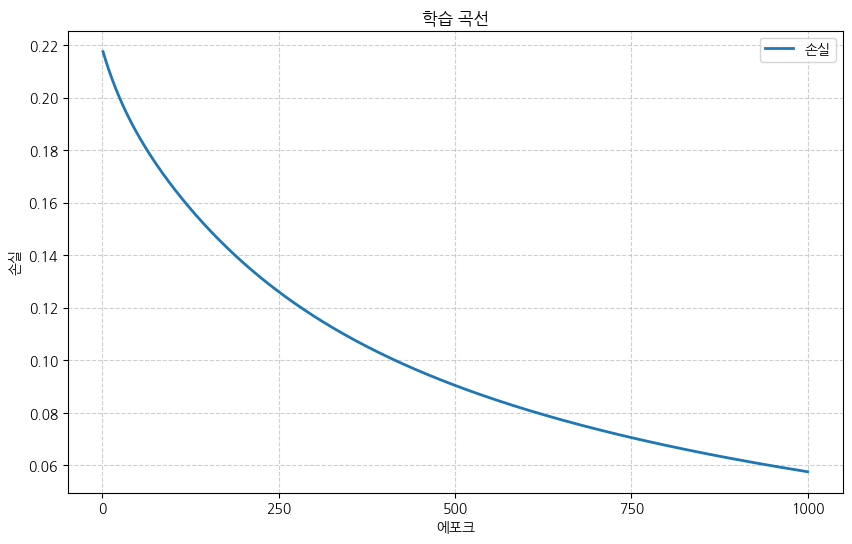

In [11]:
# 참고 - 학습 곡선 시각화
log.plot(title='학습 곡선')

- 학습 과정 해석
    - 에포크가 진행될수록 손실이 작아지고, 
    - 두 가중치는 양수로, 편향은 음수로 커지는 방향으로 수렴
    - 가중치가 양수로 커지면서 두 입력 모두 1 일 때만 가중합이 충분히 커져 1 을 출력하도록 학습됨

## 결과 확인과 시각화 ([그림 2-6], [그림 2-7])

- 학습 전 결정 경계와 학습 후 결정 경계(그림 2-6)
    - 결정 경계는 $x_1 w_1 + x_2 w_2 + b = 0$, 즉 기울기 $-w_1/w_2$, $x_2$ 절편 $-b/w_2$ 인 직선
    - 백업해 둔 학습 전 파라미터와 모델 학습 후의 파라미터로 각각 결정 경계 시각화

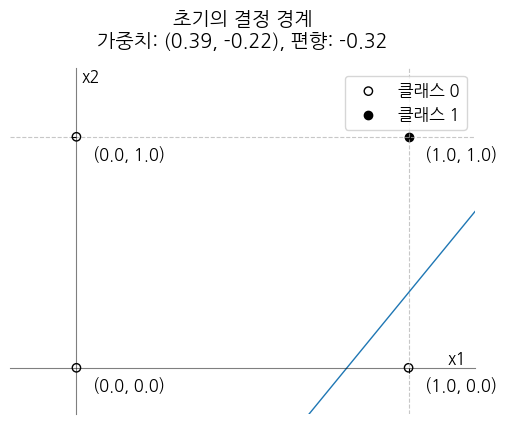

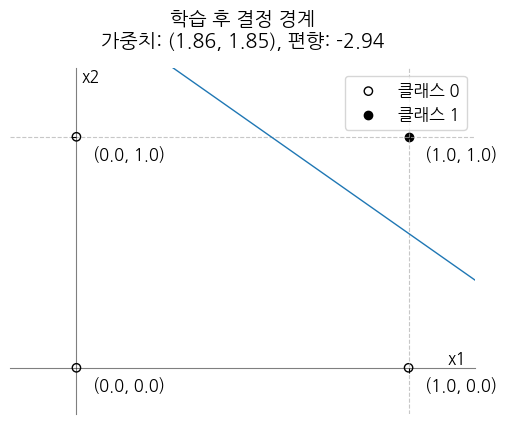

In [12]:
# 참고 - 학습 전과 후 결정 경계 비교 ([그림 2-6])

# AND 게이트 샘플 (x1, x2, y): 그래프 상에 네 점을 찍는 데이터
sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  0,  0,  1 ],   # y
)

with torch.no_grad():
    final_w1 = weights[0].item()
    final_w2 = weights[1].item()
    final_bias = bias.item()

viz.plot_decision_boundary(
    sample=sample,
    params=[
        (initial_w1, initial_w2, initial_bias),   # 학습 전        
    ],
    title=f'초기의 결정 경계\n가중치: ({initial_w1:.2f}, {initial_w2:.2f}), 편향: {initial_bias:.2f}',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.3),
    figsize=(6, 4.5)
)

viz.plot_decision_boundary(
    sample=sample,
    params=[        
        (final_w1, final_w2, final_bias),         # 학습 후
    ],    
    title=f'학습 후 결정 경계\n가중치: ({final_w1:.2f}, {final_w2:.2f}), 편향: {final_bias:.2f}',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.3),
    figsize=(6, 4.5)
)

- 9가지 초기 파라미터로 학습한 아홉 모델의 결정 경계([그림 2-7])
    - 학습할 때 마다 새로운 값으로 초기화된 파라미터를 사용

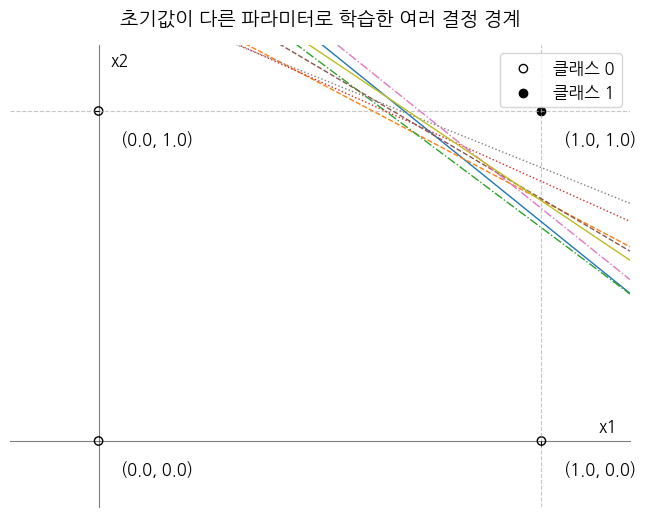

In [13]:
# 참고 - 9가지 초기 파라미터로 학습한 결정 경계 ([그림 2-7])

# 무작위 초깃값을 바꿔 9번 학습한 뒤, 각 학습의 결정 경계를 한 그림에 겹쳐 그림
torch.manual_seed(SEED)             # 9개 초깃값을 재현 가능하게 고정
boundaries = []
for _ in range(9):
    # 매 시도마다 다른 무작위 초깃값으로 파라미터 생성
    weights = torch.randn((2, 1), requires_grad=True)
    bias = torch.randn((1, ), requires_grad=True)
    # 로그 출력 없이 학습
    for epoch in range(500):
        Y_pred = model(X, weights, bias)            # 순전파
        loss = criterion(Y_pred, Y_true)            # 손실 계산
        loss.backward()                             # 역전파
        optimizer(weights, bias, LR)                # 파라미터 최적화
        weights.grad.zero_()                        # 가중치 기울기 초기화
        bias.grad.zero_()                           # 편향 기울기 초기화
    with torch.no_grad():
        boundaries.append(
            (weights[0].item(), weights[1].item(), bias.item())
        )

# AND 게이트 샘플 (x1, x2, y)
sample = (
    [0., 1., 0., 1.],   # x1
    [0., 0., 1., 1.],   # x2
    [0,  0,  0,  1 ],   # y
)

viz.plot_decision_boundary(
    sample=sample,
    params=boundaries,
    title='초기값이 다른 파라미터로 학습한 여러 결정 경계',
    x_label='x1', y_label='x2',
    x_lim=(-0.2, 1.2), y_lim=(-0.2, 1.2)
)

#### 참고 - 학습 중 결정 경계의 이동 (2-1절의 [그림 2-5])

- 학습이 진행되는 동안 결정 경계가 어떻게 이동하는지 한 그림에 겹쳐 그린다.
    - 붉은 선: 학습 초기의 결정 경계
    - 파란 선: 학습이 끝난 시점의 결정 경계
- `TRACE_SEED` 값을 바꾸면 초기 파라미터가 달라져 다른 이동 궤적을 볼 수 있다.

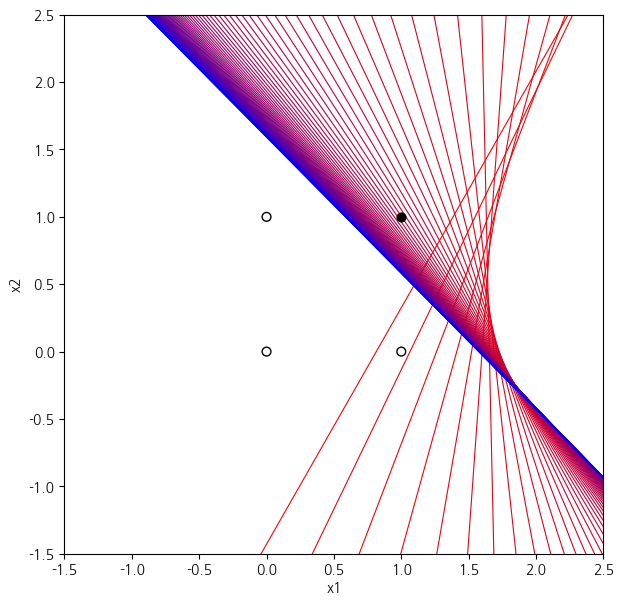

학습 후 파라미터: 가중치 (1.86, 1.85), 편향 -2.94


In [14]:
# 참고 - 학습 중 결정 경계의 이동 ([그림 2-5])

import matplotlib.pyplot as plt

from code_reference.common import set_korean_plot_env

set_korean_plot_env()

TRACE_SEED = 2         # 초기 파라미터를 결정하는 시드값 (바꿔 가며 궤적 선택)
TRACE_EPOCHS = 1000    # 학습 에포크
TRACE_LR = 0.1         # 학습률
TRACE_LINES = 80       # 그림에 그릴 결정 경계의 개수
PLOT_RANGE = (-1.5, 2.5)

# 지정한 시드로 파라미터를 새로 만들어 학습 (앞의 학습 결과에 영향을 주지 않음)
torch.manual_seed(TRACE_SEED)
trace_weights = torch.randn((2, 1), requires_grad=True)
trace_bias = torch.randn((1, ), requires_grad=True)

# 학습을 진행하면서 일정 간격마다 그 시점의 파라미터를 기록
interval = max(1, TRACE_EPOCHS // TRACE_LINES)
boundaries = []
for epoch in range(TRACE_EPOCHS):
    if epoch % interval == 0:
        with torch.no_grad():
            boundaries.append((
                trace_weights[0].item(), trace_weights[1].item(), trace_bias.item()
            ))
    Y_pred = model(X, trace_weights, trace_bias)     # 순전파
    loss = criterion(Y_pred, Y_true)                 # 손실 계산
    loss.backward()                                  # 역전파
    optimizer(trace_weights, trace_bias, TRACE_LR)   # 파라미터 최적화
    trace_weights.grad.zero_()                       # 가중치 기울기 초기화
    trace_bias.grad.zero_()                          # 편향 기울기 초기화

# 학습이 끝난 시점의 결정 경계도 기록
with torch.no_grad():
    boundaries.append((
        trace_weights[0].item(), trace_weights[1].item(), trace_bias.item()
    ))

# 결정 경계는 x1*w1 + x2*w2 + b = 0, 즉 x2 = -(w1/w2)*x1 - (b/w2) 인 직선
x_line = torch.linspace(PLOT_RANGE[0], PLOT_RANGE[1], 200)

fig, ax = plt.subplots(figsize=(7, 7))
for i, (w1, w2, b) in enumerate(boundaries):
    if w2 == 0:                                      # 수직선은 그리지 않음
        continue
    # 학습 진행도(0: 처음, 1: 마지막)에 따라 붉은색에서 푸른색으로 변화
    progress = i / (len(boundaries) - 1)
    ax.plot(x_line, -(w1 / w2) * x_line - (b / w2),
            color=(1 - progress, 0.0, progress), linewidth=0.8)

# AND 게이트 샘플: 정답이 0이면 빈 원, 1이면 채운 원
for (x1, x2), y in zip(X.tolist(), Y_true.flatten().tolist()):
    ax.scatter(x1, x2, marker='o', s=40, edgecolor='black', zorder=3,
               facecolor='black' if y > 0.5 else 'none')

ax.set_xlim(PLOT_RANGE)
ax.set_ylim(PLOT_RANGE)
ax.set_aspect('equal')
ax.set_xlabel('x1')
ax.set_ylabel('x2')
plt.show()

print(f'학습 후 파라미터: 가중치 ({boundaries[-1][0]:.2f}, {boundaries[-1][1]:.2f}), '
      f'편향 {boundaries[-1][2]:.2f}')